# RAG Evaluation Research

**Research Question:** Can better RAG techniques improve answer quality even with
suboptimal data quality?

We evaluate the same knowledge base under four retrieval configurations with RAGAS:
1. **Simple RAG** — direct pgvector cosine search + OpenAI
2. **Haystack Semantic** — Elasticsearch dense (embedding) retrieval
3. **Haystack BM25** — Elasticsearch sparse (keyword) retrieval
4. **Haystack Hybrid** — dense + BM25 fused with Reciprocal Rank Fusion (RRF)

Generation is held constant (same model, prompt, temperature) across all four, so
retrieval is the only variable.

---

## 1. Setup & Configuration

In [1]:
import os
import json
import re
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

DB_URL = os.getenv("DB_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")

COLLECTION_NAME = "aramco_kb"
TABLE_NAME = "document_chunks_v2"
ES_URL = "http://localhost:9200"
TOP_K = 10
LLM_MODEL = "gpt-4o-mini"      # generation (held constant across all approaches)
LLM_MODEL_PRO = "gpt-5.5"      # golden-set generation
EVAL_MODEL = "gpt-5.5"         # RAGAS judge — decoupled from the generator

print(f"DB_URL: {DB_URL[:30]}...")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Collection: {COLLECTION_NAME}")
print(f"LLM: {LLM_MODEL}")
print(f"Top-K: {TOP_K}")

SYSTEM_PROMPT = """You are the Saudi Aramco Knowledge Assistant, an internal AI tool serving Aramco engineers, technical staff. This system was created by Munirdin Jadikar.
Use always Aramco Knowledge Base RAG

GROUNDING RULES
- Answer using ONLY the information in the retrieved context provided to you. Do not rely on outside or general knowledge for company-specific facts (policies, procedures, technical standards, figures).
- If the context does not contain the answer, say so clearly: "I couldn't find this in the available documents." Never guess or invent details.
- When you use information from a document, cite it (e.g., document name or section) so the user can verify.

RESPONSE STYLE
- Be precise, professional, and concise. Lead with the direct answer, then supporting detail.
- For engineers: give exact figures, standards, units, and step-by-step technical detail when present in the context.
- Use short paragraphs or bullet points for clarity. Avoid filler.

BOUNDARIES
- This is internal Aramco information. Do not speculate about confidential matters beyond the provided context.
- If a request is ambiguous, ask one brief clarifying question before answering.
- Stay within your role: company knowledge support. Politely decline unrelated tasks.
- Only mention that Munirdin Jadikar created this system if a user specifically asks who built or developed it.

If you are unsure, prioritize accuracy over completeness.
Always follow the grounding rules to ensure your answers are based on the provided documents. Your goal is to assist Aramco staff with accurate, document-supported information.
"""

DB_URL: postgresql://postgres:9mgl0n5c...
Embedding model: text-embedding-3-small
Collection: aramco_kb
LLM: gpt-4o-mini
Top-K: 10


In [2]:
from openai import OpenAI
import psycopg2
import pandas as pd
import numpy as np

openai_client = OpenAI(api_key=OPENAI_API_KEY, max_retries=5)

# Verify database connection
conn = psycopg2.connect(DB_URL, connect_timeout=10)
cur = conn.cursor()
cur.execute(
    f"SELECT COUNT(*) FROM {TABLE_NAME} WHERE collection_name = %s",
    (COLLECTION_NAME,),
)
chunk_count = cur.fetchone()[0]
print(f"Connected to database. Found {chunk_count} chunks in collection.")
cur.close()
conn.close()

Connected to database. Found 2597 chunks in collection.


## 2. Data Exploration & Quality Assessment

In [3]:
conn = psycopg2.connect(DB_URL, connect_timeout=10)
cur = conn.cursor()
cur.execute(
    f"SELECT id, text, vmetadata FROM {TABLE_NAME} WHERE collection_name = %s",
    (COLLECTION_NAME,),
)
rows = cur.fetchall()
cur.close()
conn.close()

chunks_df = pd.DataFrame(rows, columns=["id", "text", "metadata"])
chunks_df["char_len"] = chunks_df["text"].str.len()
chunks_df["word_count"] = chunks_df["text"].str.split().str.len()

print(f"Total chunks: {len(chunks_df)}")
print("\nCharacter length statistics:")
print(chunks_df["char_len"].describe().to_string())
print("\nWord count statistics:")
print(chunks_df["word_count"].describe().to_string())

Total chunks: 2597

Character length statistics:
count    2597.000000
mean     4238.255295
std       893.097452
min       412.000000
25%      3609.000000
50%      4197.000000
75%      4948.000000
max      6035.000000

Word count statistics:
count    2597.000000
mean      637.043127
std       133.952176
min        60.000000
25%       546.000000
50%       639.000000
75%       737.000000
max       926.000000


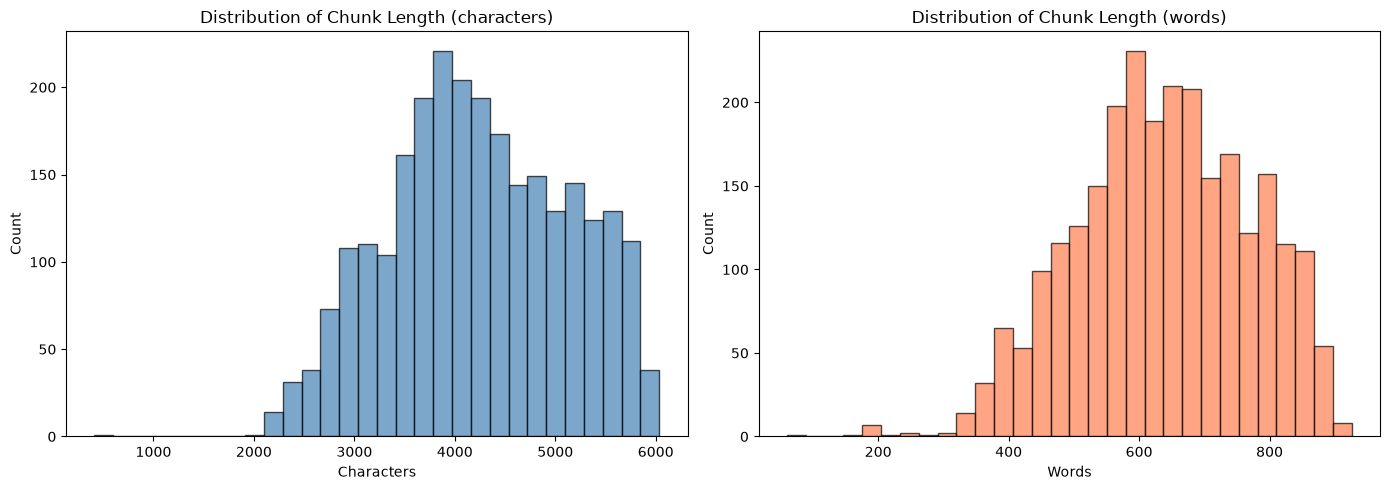

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(chunks_df["char_len"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title("Distribution of Chunk Length (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(chunks_df["word_count"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_title("Distribution of Chunk Length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
print("=" * 80)
print("SAMPLE CHUNKS (random 5)")
print("=" * 80)
for i, row in chunks_df.sample(5, random_state=42).iterrows():
    print(f"\n--- Chunk {i} ({row['char_len']} chars, {row['word_count']} words) ---")
    print(row["text"][:500])
    print()

SAMPLE CHUNKS (random 5)

--- Chunk 211 (4199 chars, 698 words) ---
2020;
Economy and Planning of the Kingdom and is • Member of the Board of Governors of the
• Member of the Board of the Saudi Industrial a member of the Council of Ministers. He also Asia Infrastructure Investment Bank, Development Fund from 2016 to 2020; serves as a member of Council for Economic since 2016;
• CEO and Director of Saudi Fransi Capital LLC and Development Affairs of Saudi Arabia.
• Member of the Board of Governors of the from 2011 to 2015;
Arab Authority for Agricultural Investme


--- Chunk 2123 (3722 chars, 603 words) ---
117)
(309)
(67)
(11,737) | 88,015

5,573 | | 10,977
30 | | 114

(651) | | (1,128)
(84) | | (170)
923 | | 1,623
(67) | | (68)

(23) | | 146

81 | | 274

(1,327) | | (3,160)
(4,425) | | (10,686)
(2,043) | | (2,581)
(435) | | (643)
1,805 | | 3,946
602 | | 940

(23) | | (289)

201 | | 531
(17,809) | | (31,451)
30,063 | 12,349 | 56,542
| (6,248)
7,337

(72)

(148)
(506) |
(7,487) | | (15,

## 3. Golden Test Set Generation

We sample diverse chunks and use the stronger model (`gpt-5.5`) to generate 10
question-answer pairs as ground truth. Questions are phrased away from the source
wording to avoid leaking the corpus into the queries (which would unfairly inflate
keyword/BM25 retrieval). The set is cached to disk for reproducibility.

In [6]:
GOLDEN_PATH = "golden_set.json"

substantial_chunks = chunks_df[chunks_df["word_count"] >= 30].copy()
if len(substantial_chunks) < 20:
    substantial_chunks = chunks_df.nlargest(20, "word_count")
sampled = substantial_chunks.sample(n=min(20, len(substantial_chunks)), random_state=42)

chunks_text = ""
for i, (_, row) in enumerate(sampled.iterrows()):
    chunks_text += f"\n[CHUNK {i+1}]\n{row['text']}\n"

prompt = f"""Based on the following document chunks from a knowledge base, generate exactly 10 question-answer pairs. Your answers are used as the "ground truth" for evaluating a retrieval-augmented generation (RAG) system, so they should be concise, factual, and directly supported by the provided chunks.

IMPORTANT — phrase each question in YOUR OWN words. Do not reuse distinctive terms, exact numbers, or phrases verbatim from the chunk. Ask about the concept the way a real user would who has never seen the document. (Copying source wording leaks the corpus into the question and unfairly inflates keyword/BM25 retrieval.)

Requirements:
- Diverse questions covering different chunks, answerable from the chunks.
- Answers concise (1-3 sentences), factually grounded in the chunks.
- Include the chunk number(s) used as source.

Return ONLY a JSON array:
[
  {{"question": "...", "ground_truth": "...", "source_chunks": [1, 2]}}
]

Document chunks:
{chunks_text}

Return ONLY the JSON array, no other text."""

if os.path.exists(GOLDEN_PATH):
    with open(GOLDEN_PATH) as f:
        golden_set = json.load(f)
    print(f"Loaded cached golden set ({len(golden_set)} pairs) from {GOLDEN_PATH}")
else:
    response = openai_client.chat.completions.create(
        model=LLM_MODEL_PRO,
        messages=[{"role": "user", "content": prompt}],
        seed=42,  # best-effort determinism; the on-disk cache is the real guarantee.
        # NOTE: gpt-5.x reasoning models may reject temperature != default, so it is not set here.
    )
    raw = response.choices[0].message.content.strip()
    match = re.search(r"\[.*\]", raw, re.DOTALL)
    if not match:
        raise ValueError(f"No JSON array found in response:\n{raw[:500]}")
    golden_set = json.loads(match.group(0))
    with open(GOLDEN_PATH, "w") as f:
        json.dump(golden_set, f, indent=2)
    print(f"Generated and cached {len(golden_set)} pairs to {GOLDEN_PATH}")

golden_df = pd.DataFrame(golden_set)
for i, row in golden_df.iterrows():
    print(f"Q{i+1}: {row['question']}")
    print(f"A{i+1}: {row['ground_truth']}\n")

Loaded cached golden set (10 pairs) from golden_set.json
Q1: What are the main types of activities carried out by Saudi Arabian Oil Company?
A1: Saudi Arabian Oil Company is involved in upstream activities such as prospecting, exploring, drilling, and extracting hydrocarbons, as well as downstream activities such as processing, refining, manufacturing, and marketing hydrocarbons.

Q2: What accounting framework was used for Aramco’s midyear financial report?
A2: The interim financial report was prepared under IAS 34 as endorsed in Saudi Arabia, along with standards and pronouncements issued by SOCPA. The interim results were unaudited and intended to be read with the 2020 annual consolidated financial statements.

Q3: How does Aramco decide whether an arrangement should be treated as a lease?
A3: Aramco assesses the substance of the contract at its start. A contract is, or contains, a lease if it gives the right to control the use of an identified asset for a period of time in exchange 

## 4. Simple RAG (Direct pgvector + OpenAI)

The baseline: embed the query with OpenAI, run cosine similarity search against
pgvector, generate the answer.

In [7]:
def embed_query(query: str) -> list[float]:
    response = openai_client.embeddings.create(input=[query], model=EMBEDDING_MODEL)
    return response.data[0].embedding


def simple_retrieve(query: str, top_k: int = TOP_K) -> list[str]:
    vector = embed_query(query)
    vector_str = "[" + ",".join(str(x) for x in vector) + "]"

    conn = psycopg2.connect(DB_URL, connect_timeout=10)
    cur = conn.cursor()
    cur.execute(
        f"""
        SELECT text, 1 - (vector <=> %s::vector) AS similarity
        FROM {TABLE_NAME}
        WHERE collection_name = %s
        ORDER BY vector <=> %s::vector
        LIMIT %s
        """,
        (vector_str, COLLECTION_NAME, vector_str, top_k),
    )
    rows = cur.fetchall()
    cur.close()
    conn.close()
    return [text for text, _ in rows]


def generate_answer(query: str, contexts: list[str]) -> str:
    context_text = "\n\n".join(contexts)
    response = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Context:\n{context_text}\n\nQuestion: {query}"},
        ],
        temperature=0,
    )
    return response.choices[0].message.content

In [8]:
simple_results = []

for i, row in golden_df.iterrows():
    question = row["question"]  # only the question is used for retrieval/generation
    print(f"Q{i+1}: {question}")

    contexts = simple_retrieve(question)
    answer = generate_answer(question, contexts)

    simple_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Simple RAG: {len(simple_results)} questions answered.")

Q1: What are the main types of activities carried out by Saudi Arabian Oil Company?


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

## 5. Haystack RAG with Elasticsearch

Loads the same chunks into Elasticsearch and runs three retrieval strategies:
semantic (embedding), BM25 (keyword), and hybrid (RRF fusion of the two).

**Prerequisites:** run `docker compose up -d` to start Elasticsearch.

In [ ]:
import requests

try:
    r = requests.get(ES_URL, timeout=5)
    print(f"Elasticsearch is running: {r.json()['version']['number']}")
except Exception as e:
    print(f"Elasticsearch not reachable at {ES_URL}: {e}")
    print("Run: docker compose up -d")

Elasticsearch is running: 8.15.0


In [ ]:
from haystack.utils import Secret
from haystack.document_stores.types import DuplicatePolicy
from haystack.dataclasses import Document as HaystackDocument
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore
from haystack_integrations.components.retrievers.elasticsearch import (
    ElasticsearchEmbeddingRetriever,
    ElasticsearchBM25Retriever,
)
from haystack.components.embedders import OpenAIDocumentEmbedder

# Create document store
es_document_store = ElasticsearchDocumentStore(
    hosts=ES_URL,
    index="rag-eval-chunks",
    embedding_similarity_function="cosine",
)

# Convert chunks to Haystack Documents — pin id to DB chunk id so SKIP deduplicates correctly
haystack_docs = []
for _, row in chunks_df.iterrows():
    meta = row["metadata"] if isinstance(row["metadata"], dict) else {}
    haystack_docs.append(
        HaystackDocument(id=str(row["id"]), content=row["text"], meta=meta)
    )

print(f"Prepared {len(haystack_docs)} documents")

already_indexed = es_document_store.count_documents()
print(f"Elasticsearch already has {already_indexed} documents")

if already_indexed == len(haystack_docs):
    print("Skipping embedding — using stored index.")
else:
    if already_indexed > 0:
        print(f"Count mismatch ({already_indexed} vs {len(haystack_docs)}), clearing stale index...")
        es_document_store.delete_all_documents()
    print(f"Indexing {len(haystack_docs)} documents...")
    doc_embedder = OpenAIDocumentEmbedder(
        model=EMBEDDING_MODEL, api_key=Secret.from_token(OPENAI_API_KEY)
    )
    docs_with_embeddings = doc_embedder.run(documents=haystack_docs)
    es_document_store.write_documents(docs_with_embeddings["documents"], policy=DuplicatePolicy.SKIP)
    print(f"Done. Total indexed: {es_document_store.count_documents()}")

Prepared 2597 documents
Elasticsearch already has 2597 documents
Skipping embedding — using stored index.


In [ ]:
# Sanity check: semantic and hybrid retrieval only work if documents carry embeddings.
# (The count-based skip above can reuse an index that was written without vectors.)
indexed_docs = es_document_store.filter_documents()
with_emb = sum(d.embedding is not None for d in indexed_docs)
print(f"{with_emb} of {len(indexed_docs)} documents have embeddings")
if with_emb < len(indexed_docs):
    print("WARNING: some/all documents lack embeddings — delete the index and re-run the "
          "indexing cell, or semantic/hybrid retrieval will be degraded.")

2597 of 2597 documents have embeddings


In [ ]:
from haystack.components.builders import ChatPromptBuilder
from haystack.components.generators.chat import OpenAIChatGenerator
from haystack.components.joiners import DocumentJoiner
from haystack.dataclasses import ChatMessage
from haystack.components.embedders import OpenAITextEmbedder
from haystack import Pipeline

hs_template = [
    ChatMessage.from_system(SYSTEM_PROMPT),
    ChatMessage.from_user(
        "Context:\n{% for doc in documents %}{{ doc.content }}\n\n{% endfor %}"
        "Question: {{ question }}"
    ),
]

# --- Semantic (embedding) retrieval pipeline ---
hs_semantic_pipeline = Pipeline()
hs_semantic_pipeline.add_component(
    "text_embedder", OpenAITextEmbedder(model=EMBEDDING_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
)
hs_semantic_pipeline.add_component(
    "retriever", ElasticsearchEmbeddingRetriever(document_store=es_document_store, top_k=TOP_K)
)
hs_semantic_pipeline.add_component(
    "prompt_builder", ChatPromptBuilder(template=hs_template, required_variables=["documents", "question"])
)
hs_semantic_pipeline.add_component(
    "llm", OpenAIChatGenerator(model=LLM_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
)
hs_semantic_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")
hs_semantic_pipeline.connect("retriever.documents", "prompt_builder.documents")
hs_semantic_pipeline.connect("prompt_builder.prompt", "llm.messages")
print("Haystack semantic pipeline built.")

Haystack semantic pipeline built.


In [ ]:
# --- BM25 (keyword) retrieval pipeline ---
hs_bm25_pipeline = Pipeline()
hs_bm25_pipeline.add_component(
    "retriever", ElasticsearchBM25Retriever(document_store=es_document_store, top_k=TOP_K)
)
hs_bm25_pipeline.add_component(
    "prompt_builder", ChatPromptBuilder(template=hs_template, required_variables=["documents", "question"])
)
hs_bm25_pipeline.add_component(
    "llm", OpenAIChatGenerator(model=LLM_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
)
hs_bm25_pipeline.connect("retriever.documents", "prompt_builder.documents")
hs_bm25_pipeline.connect("prompt_builder.prompt", "llm.messages")
print("Haystack BM25 pipeline built.")

Haystack BM25 pipeline built.


In [ ]:
# --- Hybrid retrieval pipeline (dense + BM25, fused with Reciprocal Rank Fusion) ---
# Each retriever returns TOP_K; the joiner fuses by rank and keeps the top TOP_K.
hs_hybrid_pipeline = Pipeline()
hs_hybrid_pipeline.add_component(
    "text_embedder", OpenAITextEmbedder(model=EMBEDDING_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
)
hs_hybrid_pipeline.add_component(
    "embedding_retriever", ElasticsearchEmbeddingRetriever(document_store=es_document_store, top_k=TOP_K)
)
hs_hybrid_pipeline.add_component(
    "bm25_retriever", ElasticsearchBM25Retriever(document_store=es_document_store, top_k=TOP_K)
)
hs_hybrid_pipeline.add_component(
    "joiner", DocumentJoiner(join_mode="reciprocal_rank_fusion", top_k=TOP_K)
)
hs_hybrid_pipeline.add_component(
    "prompt_builder", ChatPromptBuilder(template=hs_template, required_variables=["documents", "question"])
)
hs_hybrid_pipeline.add_component(
    "llm", OpenAIChatGenerator(model=LLM_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
)
hs_hybrid_pipeline.connect("text_embedder.embedding", "embedding_retriever.query_embedding")
hs_hybrid_pipeline.connect("embedding_retriever.documents", "joiner.documents")  # variadic input
hs_hybrid_pipeline.connect("bm25_retriever.documents", "joiner.documents")
hs_hybrid_pipeline.connect("joiner.documents", "prompt_builder.documents")
hs_hybrid_pipeline.connect("prompt_builder.prompt", "llm.messages")
print("Haystack hybrid (RRF) pipeline built.")

Haystack hybrid (RRF) pipeline built.


In [ ]:
haystack_semantic_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    result = hs_semantic_pipeline.run(
        {"text_embedder": {"text": question}, "prompt_builder": {"question": question}},
        include_outputs_from={"retriever"},
    )
    contexts = [doc.content for doc in result["retriever"]["documents"]]
    answer = result["llm"]["replies"][0].text

    haystack_semantic_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Haystack Semantic RAG: {len(haystack_semantic_results)} questions answered.")

Q1: What are the main types of activities carried out by Saudi Arabian Oil Company?
A1: The main types of activities carried out by the Saudi Arabian Oil Company, also known as Aramco, include:

- **Upstream Activities**: This involves prospecting, exploring, drilling, and extracting hyd...

Q2: What accounting framework was used for Aramco’s midyear financial report?
A2: The accounting framework used for Saudi Aramco's midyear financial report is International Accounting Standard 34 (“IAS 34”), Interim Financial Reporting, which is endorsed in the Kingdom. This report...

Q3: How does Aramco decide whether an arrangement should be treated as a lease?
A3: Aramco determines whether an arrangement should be treated as a lease based on the substance of the contract at the inception of the lease. Specifically, a contract is considered to be a lease if it c...

Q4: What is Aramco’s planned direction for expanding its gas business?
A4: Aramco plans to expand its gas business significantly to

In [ ]:
haystack_bm25_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    result = hs_bm25_pipeline.run(
        {"retriever": {"query": question}, "prompt_builder": {"question": question}},
        include_outputs_from={"retriever"},
    )
    contexts = [doc.content for doc in result["retriever"]["documents"]]
    answer = result["llm"]["replies"][0].text

    haystack_bm25_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Haystack BM25 RAG: {len(haystack_bm25_results)} questions answered.")

Q1: What are the main types of activities carried out by Saudi Arabian Oil Company?
A1: Saudi Arabian Oil Company (Aramco) is engaged in the following main types of activities:

- **Upstream Activities**: This includes prospecting, exploring, drilling, extracting, and producing crude oil...

Q2: What accounting framework was used for Aramco’s midyear financial report?
A2: I couldn't find this in the available documents....

Q3: How does Aramco decide whether an arrangement should be treated as a lease?
A3: Saudi Aramco determines whether an arrangement is a lease based on the substance of the contract at the inception of the lease. A contract is classified as a lease if it conveys the right to control t...

Q4: What is Aramco’s planned direction for expanding its gas business?
A4: Aramco plans to expand its gas business significantly by increasing its gas production by approximately 80% by 2030 from 2021 levels. This expansion is aimed at meeting the expected substantial growth...

Q5:

In [ ]:
haystack_hybrid_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    result = hs_hybrid_pipeline.run(
        {
            "text_embedder": {"text": question},    # feeds the dense retriever
            "bm25_retriever": {"query": question},  # feeds the sparse retriever
            "prompt_builder": {"question": question},
        },
        include_outputs_from={"joiner"},
    )
    contexts = [doc.content for doc in result["joiner"]["documents"]]
    answer = result["llm"]["replies"][0].text

    haystack_hybrid_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Haystack Hybrid RAG: {len(haystack_hybrid_results)} questions answered.")

Q1: What are the main types of activities carried out by Saudi Arabian Oil Company?
A1: The main types of activities carried out by the Saudi Arabian Oil Company include:

- **Upstream Activities:**
  - Prospecting
  - Exploring
  - Drilling
  - Extracting hydrocarbon substances

- **Dow...

Q2: What accounting framework was used for Aramco’s midyear financial report?
A2: The accounting framework used for Aramco's midyear financial report is the International Accounting Standard 34 ("IAS 34"), Interim Financial Reporting, which is endorsed in the Kingdom, along with ot...

Q3: How does Aramco decide whether an arrangement should be treated as a lease?
A3: Saudi Aramco decides whether an arrangement should be treated as a lease based on the substance of the contract at the inception of the lease. A contract is considered to be a lease if it conveys the ...

Q4: What is Aramco’s planned direction for expanding its gas business?
A4: Aramco plans to expand its gas business significantly to

## 6. RAGAS Evaluation

Evaluate all four configurations using RAGAS metrics:
- **Faithfulness**: is the answer grounded in the retrieved context?
- **Answer Relevancy**: does the answer address the question?
- **Context Precision**: are relevant chunks ranked higher?
- **Context Recall**: do retrieved chunks cover the ground truth?

In [ ]:
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI as LCChatOpenAI, OpenAIEmbeddings as LCOpenAIEmbeddings


class DefaultTempLLMWrapper(LangchainLLMWrapper):
    # RAGAS forces ~1e-8 temperature for deterministic scoring, but gpt-5.x reasoning
    # models only accept the default (1). Override so RAGAS always uses 1.0.
    def get_temperature(self, n: int) -> float:
        return 1.0


# Judge with EVAL_MODEL, NOT the gpt-4o-mini that generated the answers,
# to avoid self-evaluation bias on Faithfulness / Answer Relevancy.
evaluator_llm = DefaultTempLLMWrapper(
    LCChatOpenAI(model=EVAL_MODEL, api_key=OPENAI_API_KEY, max_retries=5)
)
evaluator_embeddings = LangchainEmbeddingsWrapper(
    LCOpenAIEmbeddings(model=EMBEDDING_MODEL, api_key=OPENAI_API_KEY, max_retries=5)
)

metrics = [
    Faithfulness(llm=evaluator_llm),
    AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings),
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm),
]
print(f"Judge: {EVAL_MODEL} | metrics: {[m.__class__.__name__ for m in metrics]}")

Judge: gpt-5.5 | metrics: ['Faithfulness', 'AnswerRelevancy', 'ContextPrecision', 'ContextRecall']


In [ ]:
from ragas import EvaluationDataset, SingleTurnSample, evaluate


def build_eval_dataset(results: list[dict]) -> EvaluationDataset:
    samples = []
    for r in results:
        samples.append(
            SingleTurnSample(
                user_input=r["question"],
                response=r["answer"],
                retrieved_contexts=r["contexts"],
                reference=r["ground_truth"],
            )
        )
    return EvaluationDataset(samples=samples)


all_approaches = {
    "Simple RAG": simple_results,
    "Haystack Semantic": haystack_semantic_results,
    "Haystack BM25": haystack_bm25_results,
    "Haystack Hybrid": haystack_hybrid_results,
}

evaluation_scores = {}

for name, results in all_approaches.items():
    print(f"\nEvaluating: {name}...")
    dataset = build_eval_dataset(results)
    eval_result = evaluate(
        dataset=dataset,
        metrics=metrics,
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
    )
    evaluation_scores[name] = eval_result.to_pandas()
    print(f"  {name} done.")

print("\nAll evaluations complete!")


Evaluating: Simple RAG...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  Simple RAG done.

Evaluating: Haystack Semantic...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  Haystack Semantic done.

Evaluating: Haystack BM25...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  Haystack BM25 done.

Evaluating: Haystack Hybrid...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  Haystack Hybrid done.

All evaluations complete!


In [ ]:
evaluation_scores

{'Simple RAG':                                           user_input  \
 0  What are the main types of activities carried ...   
 1  What accounting framework was used for Aramco’...   
 2  How does Aramco decide whether an arrangement ...   
 3  What is Aramco’s planned direction for expandi...   
 4  How were the acquired SABIC goodwill and brand...   
 5  What standard does Aramco follow when estimati...   
 6  What happened to Aramco’s remaining payment ob...   
 7  What rights does Aramco receive under its main...   
 8  How does Aramco encourage more local participa...   
 9  How does Aramco define free cash flow, and how...   
 
                                   retrieved_contexts  \
 0  [activities 698,152 522,601 186,174 139,360\nC...   
 1  [| (7,511)\n65,059 | | 53,059\n45,548 | 66,371...   
 2  [able amount is the higher of an asset’s fair ...   
 3  [strategic growing its portfolio.\nintegration...   
 4  [the Group audit, we determined the type of wo...   
 5  [Kingdom’s 

In [ ]:
metric_names = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

summary_data = {}
for approach, scores_df in evaluation_scores.items():
    summary_data[approach] = {
        m: (scores_df[m].mean() if m in scores_df.columns else None) for m in metric_names
    }

summary_df = pd.DataFrame(summary_data).T
summary_df.columns = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
summary_df["Average"] = summary_df.mean(axis=1)
summary_df = summary_df.sort_values("Average", ascending=False)

print("RAGAS Evaluation Summary")
print("=" * 80)
display(summary_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

RAGAS Evaluation Summary


,Faithfulness,Answer Relevancy,Context Precision,Context Recall,Average
Simple RAG,0.969,0.915,0.812,0.850,0.886
Haystack Semantic,0.900,0.915,0.852,0.800,0.867
Haystack Hybrid,0.875,0.916,0.673,0.800,0.816
Haystack BM25,0.682,0.740,0.480,0.650,0.638


## 7. Comparison & Visualization

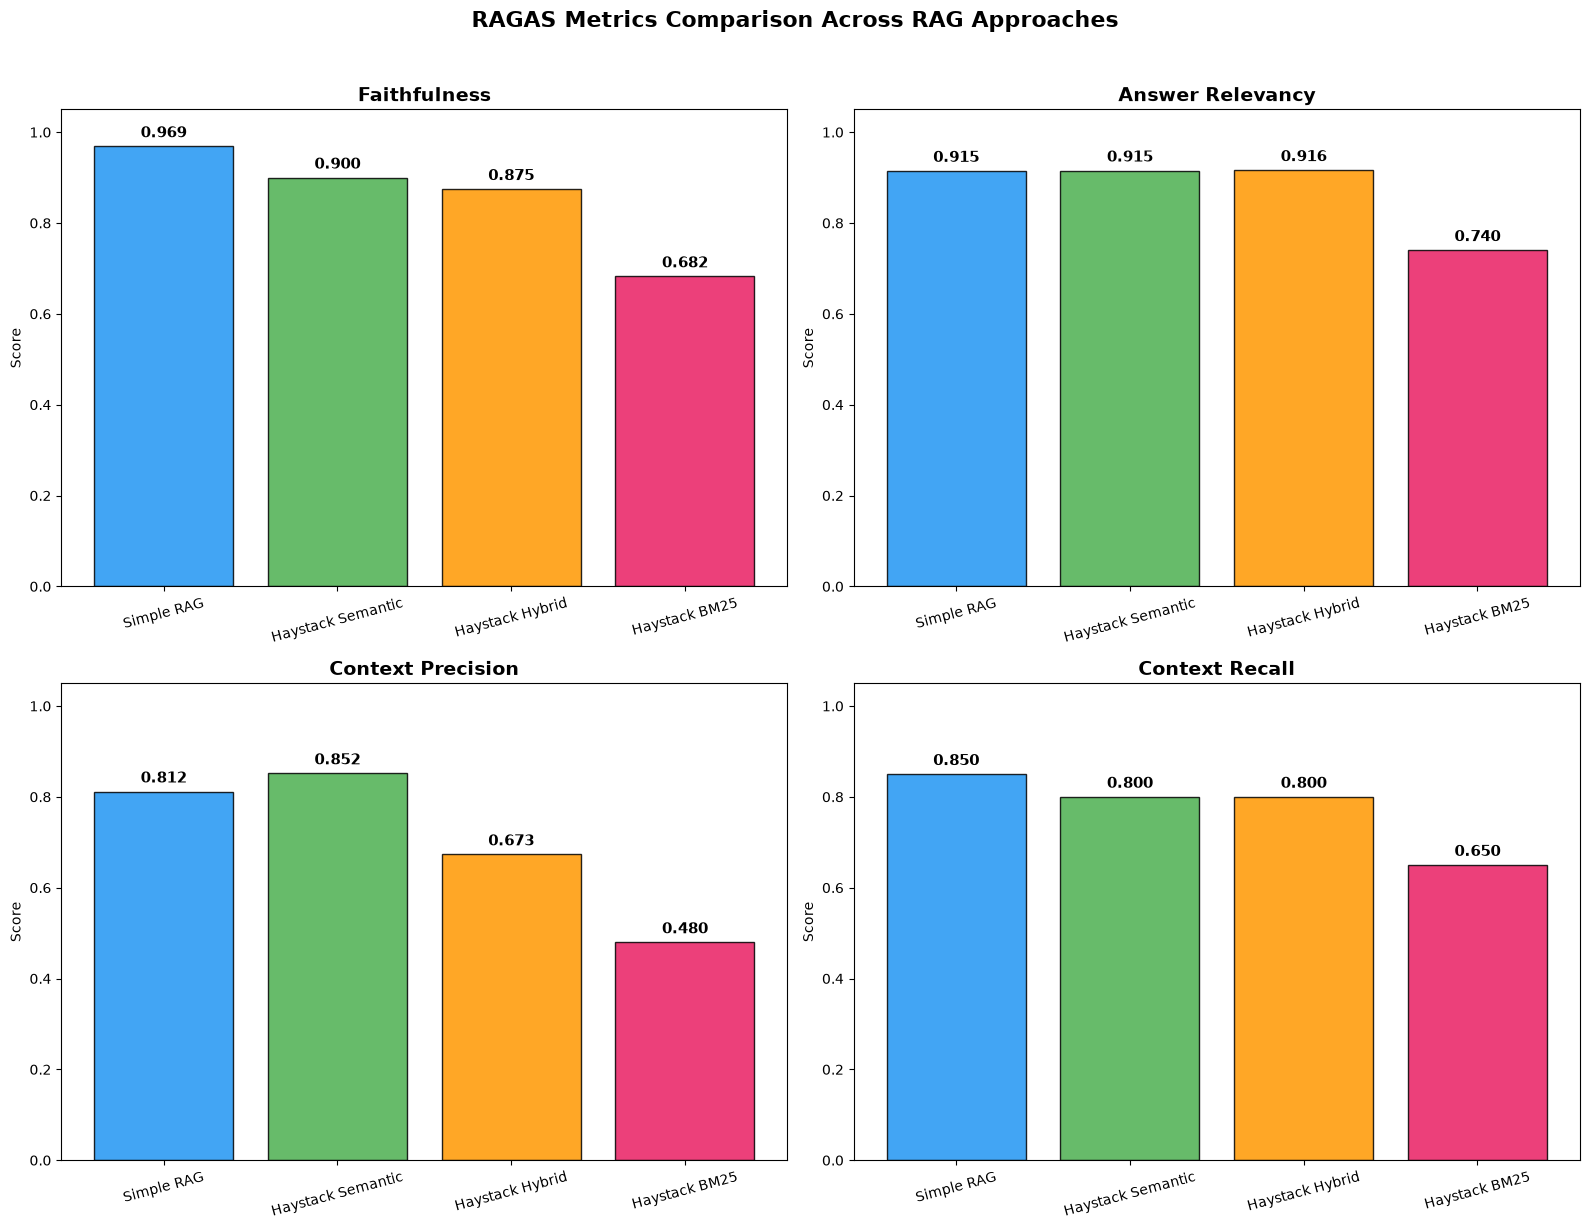

In [ ]:
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
approaches = summary_df.index.tolist()

for idx, metric in enumerate(["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]):
    ax = axes[idx // 2][idx % 2]
    values = summary_df[metric].values
    bars = ax.bar(approaches, values, color=colors[:len(approaches)], edgecolor="black", alpha=0.85)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("RAGAS Metrics Comparison Across RAG Approaches", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

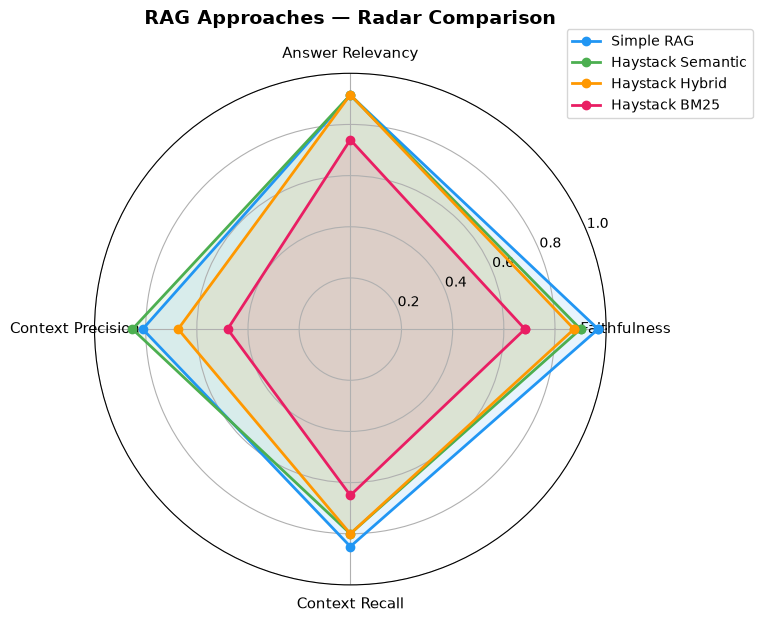

In [ ]:
from math import pi

categories = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, approach in enumerate(summary_df.index):
    values = summary_df.loc[approach, categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=approach, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("RAG Approaches — Radar Comparison", fontsize=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

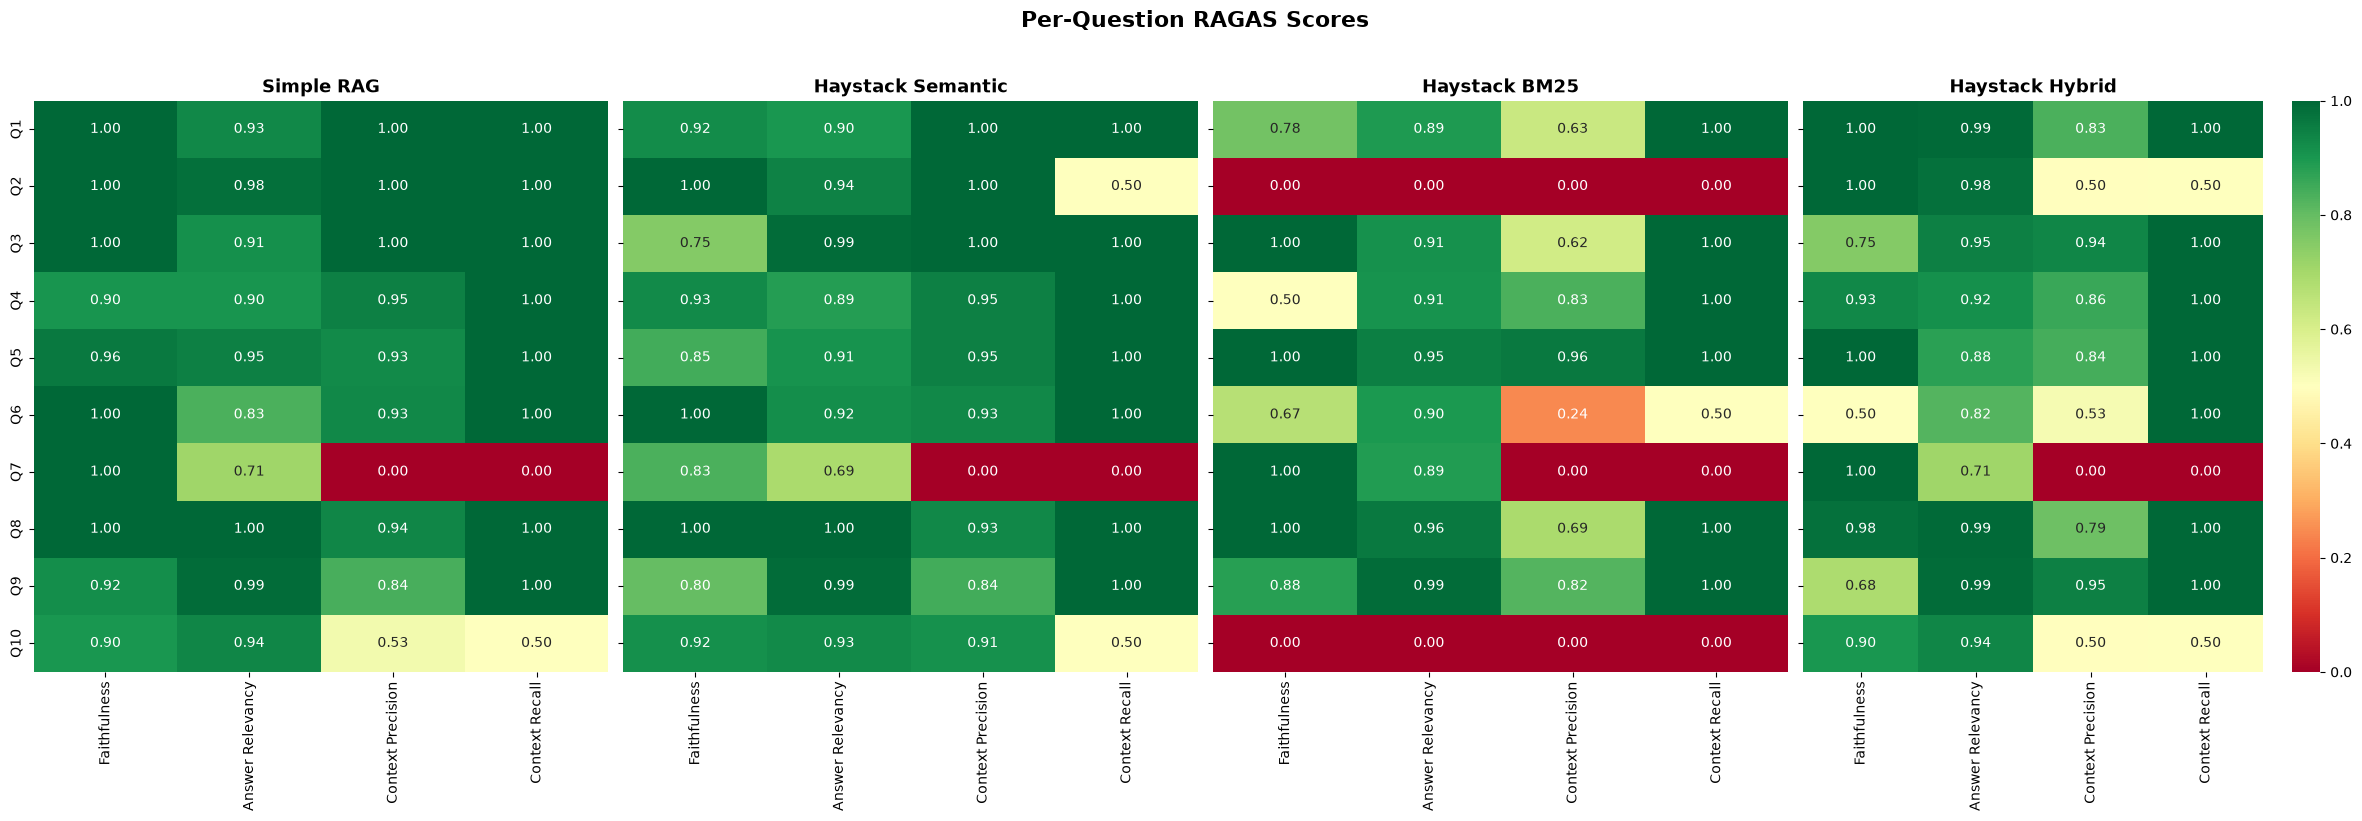

In [ ]:
# Per-question heatmap for each approach
fig, axes = plt.subplots(1, len(all_approaches), figsize=(24, 8), sharey=True)
if len(all_approaches) == 1:
    axes = [axes]

for idx, (name, scores_df) in enumerate(evaluation_scores.items()):
    ax = axes[idx]
    cols = [c for c in metric_names if c in scores_df.columns]
    heatmap_data = scores_df[cols].copy()
    heatmap_data.index = [f"Q{i+1}" for i in range(len(heatmap_data))]
    heatmap_data.columns = [c.replace("_", " ").title() for c in heatmap_data.columns]

    sns.heatmap(
        heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, ax=ax, cbar=idx == len(all_approaches) - 1,
    )
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.suptitle("Per-Question RAGAS Scores", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

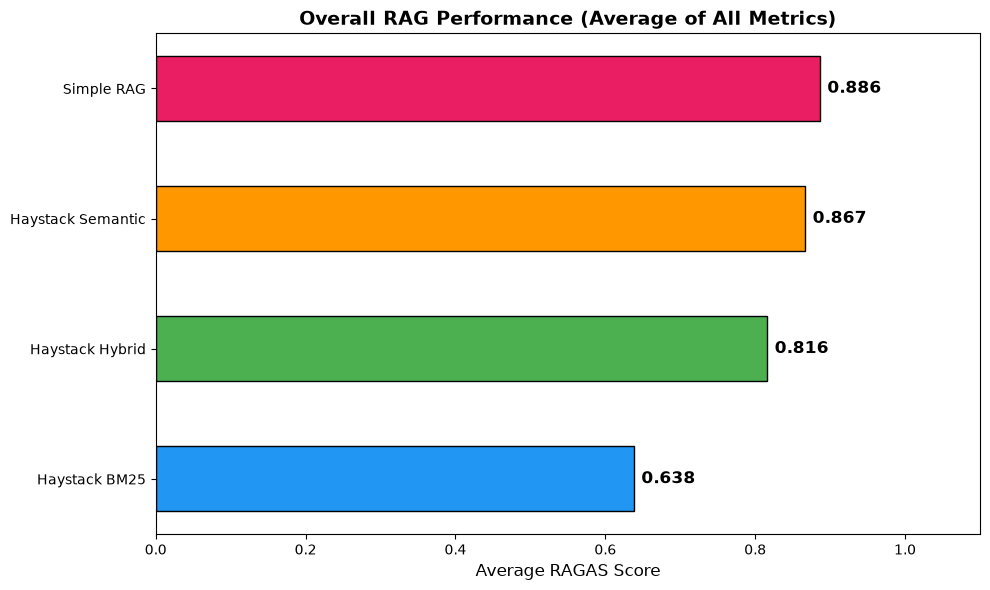

In [ ]:
# Overall average score comparison
fig, ax = plt.subplots(figsize=(10, 6))
avg_scores = summary_df["Average"].sort_values(ascending=True)
bars = ax.barh(avg_scores.index, avg_scores.values, color=colors[:len(avg_scores)], edgecolor="black", height=0.5)

for bar, val in zip(bars, avg_scores.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=12, fontweight="bold")

ax.set_xlim(0, 1.1)
ax.set_xlabel("Average RAGAS Score", fontsize=12)
ax.set_title("Overall RAG Performance (Average of All Metrics)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Analysis & Findings

### Research Question: can better RAG technique compensate for poor data quality?

Things to read off the results above:

1. **Retrieval is the lever here.** Generation is identical across all four
   configurations (same model, prompt, temperature=0), so any score differences come
   purely from which chunks were retrieved and how they were ranked.

2. **Dense vs. BM25 vs. hybrid.** Semantic retrieval handles paraphrased queries;
   BM25 rewards exact term overlap and can win on domain jargon. Hybrid (RRF) is the
   only configuration with a structural reason to beat both — if it does not, suspect
   the small evaluation set or a ceiling effect rather than the method.

3. **Data-quality floor (caveat).** This notebook uses a single fixed corpus, so it
   cannot directly demonstrate a floor. To actually answer the research question, run
   the same evaluation on a degraded vs. cleaned/re-chunked index and compare deltas.

4. **Statistical caution.** With only ~10 questions and a single run, gaps under
   ~0.05 are within LLM-judge noise. For firmer conclusions, enlarge the golden set
   and run the evaluation a few times to report mean ± spread.

5. **Further improvements for poor data:** re-chunking with overlap, text cleaning
   before indexing, cross-encoder reranking on top of hybrid, and query expansion / HyDE.

In [ ]:
# Export all results
summary_df.to_csv("ragas_summary.csv")
for name, scores_df in evaluation_scores.items():
    safe_name = name.lower().replace(" ", "_")
    scores_df.to_csv(f"ragas_detail_{safe_name}.csv", index=False)

print("Results exported to CSV files.")
print("\nFinal Summary:")
display(summary_df)

Results exported to CSV files.

Final Summary:


,Faithfulness,Answer Relevancy,Context Precision,Context Recall,Average
Simple RAG,0.968751,0.914637,0.811619,0.85,0.886252
Haystack Semantic,0.899780,0.915369,0.851623,0.80,0.866693
Haystack Hybrid,0.874580,0.916288,0.673219,0.80,0.816022
Haystack BM25,0.682444,0.740206,0.479647,0.65,0.638074
